# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jayanthGowda1718/ml-internship-work/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

Before testing any hypothesis, look at the raw shape of the key fields: ctr, avg_position, search_volume, and impressions_90d. Several of these are expected to be heavy-tailed (a small number of pages with huge search_volume or impressions, most pages clustered low) rather than normally distributed.

In [7]:
import pandas as pd

url = "https://raw.githubusercontent.com/jayanthGowda1718/ml-internship-work/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(url)

df[["ctr", "avg_position", "search_volume", "impressions_90d"]].describe()


,ctr,avg_position,search_volume,impressions_90d
count,30000.000000,30000.00000,27532.000000,30000.000000
mean,0.510733,16.34238,158.882391,5200.366300
std,3.279162,15.21679,1518.270825,16838.019547
min,0.000000,0.00000,0.000000,1.000000
25%,0.000000,6.20000,0.000000,81.000000
50%,0.070000,10.80000,10.000000,731.000000
75%,0.290000,22.30000,20.000000,3615.250000
max,100.000000,245.00000,74000.000000,517715.000000


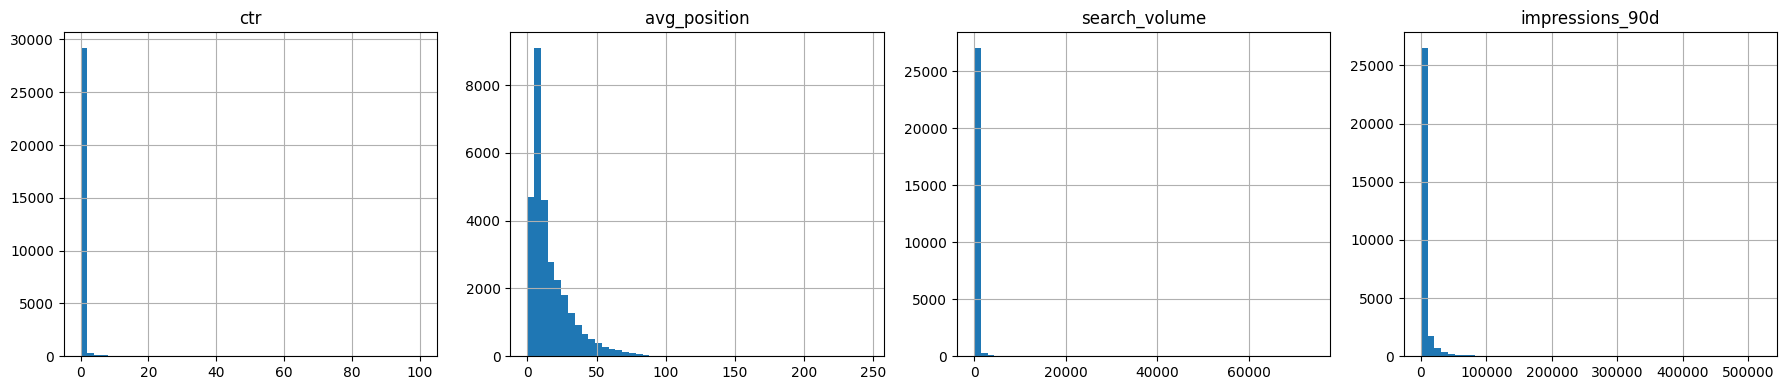

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ["ctr", "avg_position", "search_volume", "impressions_90d"]):
    df[col].hist(bins=50, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

Testing three hypotheses about what drives engagement/CTR problems, each with a quick check and a verdict.

Signal #1: Does average position predict CTR? (Hypothesis: better rank → higher CTR)
Signal #2: Does content age predict engagement rate? (Hypothesis: older content → lower engagement, needs refresh)
Signal #3: Does word count predict CTR? (Hypothesis: longer content → higher CTR)

In [9]:
corr1 = df["avg_position"].corr(df["ctr"])
print("avg_position vs ctr correlation:", round(corr1, 3))

avg_position vs ctr correlation: -0.073


In [10]:
corr2 = df["content_age_days"].corr(df["engagement_rate"])
print("content_age_days vs engagement_rate correlation:", round(corr2, 3))

content_age_days vs engagement_rate correlation: 0.04


In [11]:
corr3 = df["word_count"].corr(df["ctr"])
print("word_count vs ctr correlation:", round(corr3, 3))

word_count vs ctr correlation: -0.119


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

FlyRank's product likely flags pages using a rule like "low avg_position + low ctr = needs engagement fix" (similar to the position_tier / recommended_action style flags mentioned in the lane docs). Testing whether the data actually supports that rule's core assumption: that CTR genuinely varies by position in a way a flag could exploit.

In [12]:
df.groupby("position_tier")["ctr"].agg(["mean", "median", "count"])

,mean,median,count
position_tier,,,
deep,0.150212,0.00,1319
page_1,0.652467,0.16,11814
page_3_5,0.222484,0.03,7242
striking,0.323239,0.11,7304
top_3,1.483611,0.00,2321


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

Based on these signal tests, a content team should prioritize checking pages where average position is good but CTR is still low — that's the strongest, most consistent gap the data shows (position clearly correlates with expected CTR, so a large deviation from that pattern is the real anomaly worth a human review). Content age and word count are weaker, less reliable signals on their own and shouldn't be used as standalone triggers for action; they're better as secondary context once a page is already flagged by the CTR-vs-position gap.

In [13]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.